In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../data/processed/engineered_returns.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (2325165, 31)


In [2]:
for col in df.columns:
    print(col)

orderID
orderDate
articleID
colorCode
sizeCode
productGroup
quantity
price
rrp
voucherID
voucherAmount
customerID
deviceID
paymentMethod
returnQuantity
returned
order_month
order_day
order_dayofweek
order_weekend
rrp_missing
price_above_rrp
discount_pct
customer_previous_orders
customer_previous_items
customer_previous_returns
customer_historical_return_rate
product_previous_orders
product_previous_items
product_previous_returns
product_historical_return_rate


In [3]:
print("\nTarget distribution:")
print(df["returned"].value_counts(normalize=True) * 100)


Target distribution:
returned
1    51.953689
0    48.046311
Name: proportion, dtype: float64


In [4]:
features = [
    "productGroup",
    "quantity",
    "price",
    "rrp",
    "voucherAmount",
    "deviceID",
    "paymentMethod",
    "order_month",
    "order_dayofweek",
    "order_weekend",
    "discount_pct",
    "price_above_rrp",
    "rrp_missing",
    "customer_previous_orders",
    "customer_previous_items",
    "customer_previous_returns",
    "customer_historical_return_rate",
    "product_previous_orders",
    "product_previous_items",
    "product_previous_returns",
    "product_historical_return_rate"
]

target = "returned"

print("Number of features:", len(features))

Number of features: 21


In [5]:
df["orderDate"] = pd.to_datetime(df["orderDate"])

print("First date:", df["orderDate"].min())
print("Last date:", df["orderDate"].max())

First date: 2014-01-01 00:00:00
Last date: 2015-09-30 00:00:00


In [6]:
df["orderDate"].describe()

count                       2325165
mean     2014-11-28 16:24:12.643232
min             2014-01-01 00:00:00
25%             2014-06-17 00:00:00
50%             2014-11-27 00:00:00
75%             2015-05-14 00:00:00
max             2015-09-30 00:00:00
Name: orderDate, dtype: object

In [7]:
print("First date:", df["orderDate"].min())
print("Last date:", df["orderDate"].max())

First date: 2014-01-01 00:00:00
Last date: 2015-09-30 00:00:00


In [8]:
cutoff_date = pd.Timestamp("2015-07-01")

train_df = df[df["orderDate"] < cutoff_date].copy()
test_df = df[df["orderDate"] >= cutoff_date].copy()

print("Training rows:", f"{len(train_df):,}")
print("Testing rows: ", f"{len(test_df):,}")

print("\nTraining period:")
print(train_df["orderDate"].min(), "to", train_df["orderDate"].max())

print("\nTesting period:")
print(test_df["orderDate"].min(), "to", test_df["orderDate"].max())

Training rows: 1,955,978
Testing rows:  369,187

Training period:
2014-01-01 00:00:00 to 2015-06-30 00:00:00

Testing period:
2015-07-01 00:00:00 to 2015-09-30 00:00:00


In [9]:
print("TRAIN return distribution:")
print(train_df["returned"].value_counts(normalize=True) * 100)

print("\nTEST return distribution:")
print(test_df["returned"].value_counts(normalize=True) * 100)

TRAIN return distribution:
returned
1    52.127734
0    47.872266
Name: proportion, dtype: float64

TEST return distribution:
returned
1    51.031591
0    48.968409
Name: proportion, dtype: float64


In [10]:
categorical_features = [
    "productGroup",
    "deviceID",
    "paymentMethod"
]

numerical_features = [
    "quantity",
    "price",
    "rrp",
    "voucherAmount",
    "order_month",
    "order_dayofweek",
    "order_weekend",
    "discount_pct",
    "price_above_rrp",
    "rrp_missing",
    "customer_previous_orders",
    "customer_previous_items",
    "customer_previous_returns",
    "customer_historical_return_rate",
    "product_previous_orders",
    "product_previous_items",
    "product_previous_returns",
    "product_historical_return_rate"
]

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))
print("Total features:", len(categorical_features) + len(numerical_features))

Categorical features: 3
Numerical features: 18
Total features: 21


In [11]:
model_features = numerical_features + categorical_features

X_train = train_df[model_features]
y_train = train_df["returned"]

X_test = test_df[model_features]
y_test = test_df["returned"]

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (1955978, 21)
X_test:  (369187, 21)
y_train: (1955978,)
y_test:  (369187,)


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

In [13]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessor ready!")

Preprocessor ready!


In [14]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=500,
        solver="saga",
        n_jobs=-1,
        random_state=42
    ))
])

print("Baseline model ready!")

Baseline model ready!


In [15]:
print("Training Logistic Regression...")

baseline_model.fit(X_train, y_train)

print("Training complete!")

Training Logistic Regression...


Training complete!


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("Evaluation metrics imported!")

Evaluation metrics imported!


In [17]:
print("Generating predictions...")

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("Predictions complete!")

Generating predictions...
Predictions complete!


In [18]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")

Accuracy:  0.6498
Precision: 0.6419
Recall:    0.7096
F1 Score:  0.6741
ROC-AUC:   0.7061
PR-AUC:    0.6861


In [19]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[106195  74590]
 [ 54703 133699]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.59      0.62    180785
           1       0.64      0.71      0.67    188402

    accuracy                           0.65    369187
   macro avg       0.65      0.65      0.65    369187
weighted avg       0.65      0.65      0.65    369187



In [20]:
baseline_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc,
    "PR_AUC": pr_auc
}

baseline_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.6497899438495939,
 'Precision': 0.6418917945738853,
 'Recall': 0.709647455971805,
 'F1': 0.674071254452458,
 'ROC_AUC': 0.7060569612895597,
 'PR_AUC': 0.6861354597518703}

In [21]:
from xgboost import XGBClassifier

In [22]:
xgb_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

xgb_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

xgb_preprocessor = ColumnTransformer([
    ("num", xgb_numeric_pipeline, numerical_features),
    ("cat", xgb_categorical_pipeline, categorical_features)
])

In [23]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

xgb_pipeline = Pipeline([
    ("preprocessor", xgb_preprocessor),
    ("classifier", xgb_model)
])

print("XGBoost pipeline ready!")

XGBoost pipeline ready!


In [24]:
sample_size = min(500_000, len(X_train))

X_train_sample = X_train.sample(
    n=sample_size,
    random_state=42
)

y_train_sample = y_train.loc[X_train_sample.index]

print("Training sample:", X_train_sample.shape)
print("Full test set:", X_test.shape)

Training sample: (500000, 21)
Full test set: (369187, 21)


In [25]:
print("Training XGBoost...")

xgb_pipeline.fit(
    X_train_sample,
    y_train_sample
)

print("XGBoost training complete!")

Training XGBoost...
XGBoost training complete!


In [26]:
print("Generating XGBoost predictions...")

xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

print("Predictions complete!")

Generating XGBoost predictions...
Predictions complete!


In [27]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_prob)
xgb_pr_auc = average_precision_score(y_test, xgb_prob)

print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1 Score:  {xgb_f1:.4f}")
print(f"ROC-AUC:   {xgb_roc_auc:.4f}")
print(f"PR-AUC:    {xgb_pr_auc:.4f}")

Accuracy:  0.6612
Precision: 0.6468
Recall:    0.7402
F1 Score:  0.6904
ROC-AUC:   0.7226
PR-AUC:    0.7067


In [28]:
comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    },
    {
        "Model": "XGBoost",
        "Accuracy": xgb_accuracy,
        "Precision": xgb_precision,
        "Recall": xgb_recall,
        "F1": xgb_f1,
        "ROC-AUC": xgb_roc_auc,
        "PR-AUC": xgb_pr_auc
    }
])

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.6498,0.6419,0.7096,0.6741,0.7061,0.6861
1,XGBoost,0.6612,0.6468,0.7402,0.6904,0.7226,0.7067


In [29]:
print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nXGBoost Classification Report:")
print(classification_report(y_test, xgb_pred))

XGBoost Confusion Matrix:
[[104643  76142]
 [ 48954 139448]]

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.58      0.63    180785
           1       0.65      0.74      0.69    188402

    accuracy                           0.66    369187
   macro avg       0.66      0.66      0.66    369187
weighted avg       0.66      0.66      0.66    369187



In [30]:
probability_check = pd.DataFrame({
    "actual_returned": y_test.values,
    "return_probability": xgb_prob
})

probability_check["risk_score"] = (
    probability_check["return_probability"] * 100
).round(1)

probability_check.head(20)

,actual_returned,return_probability,risk_score
0,1,0.169238,16.900000
1,1,0.398133,39.799999
2,0,0.323854,32.400002
3,0,0.313078,31.299999
4,0,0.748443,74.800003
5,0,0.704486,70.400002
6,1,0.678217,67.800003
7,1,0.786633,78.699997
8,1,0.741240,74.099998
9,1,0.849815,85.000000


In [31]:
def assign_risk_level(probability):
    if probability < 0.30:
        return "Low"
    elif probability < 0.60:
        return "Medium"
    else:
        return "High"


probability_check["risk_level"] = (
    probability_check["return_probability"]
    .apply(assign_risk_level)
)

probability_check.head(20)

,actual_returned,return_probability,risk_score,risk_level
0,1,0.169238,16.900000,Low
1,1,0.398133,39.799999,Medium
2,0,0.323854,32.400002,Medium
3,0,0.313078,31.299999,Medium
4,0,0.748443,74.800003,High
5,0,0.704486,70.400002,High
6,1,0.678217,67.800003,High
7,1,0.786633,78.699997,High
8,1,0.741240,74.099998,High
9,1,0.849815,85.000000,High


In [32]:
probability_check["risk_level"].value_counts()

risk_level
Medium    164793
High      141957
Low        62437
Name: count, dtype: int64

In [33]:
risk_validation = (
    probability_check
    .groupby("risk_level")
    .agg(
        orders=("actual_returned", "count"),
        actual_return_rate=("actual_returned", "mean"),
        average_predicted_risk=("return_probability", "mean")
    )
)

risk_validation["actual_return_rate"] *= 100
risk_validation["average_predicted_risk"] *= 100

risk_validation.round(2)

,orders,actual_return_rate,average_predicted_risk
risk_level,,,
High,141957,69.63,70.209999
Low,62437,17.31,15.750000
Medium,164793,47.79,47.340000


In [34]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

MODEL_PATH = "../models/xgboost_return_risk_pipeline.joblib"

joblib.dump(xgb_pipeline, MODEL_PATH)

print("Model saved successfully!")
print(MODEL_PATH)

Model saved successfully!
../models/xgboost_return_risk_pipeline.joblib


In [35]:
model_size = os.path.getsize(MODEL_PATH) / (1024 * 1024)

print(f"Model size: {model_size:.2f} MB")

Model size: 1.16 MB


In [36]:
trained_preprocessor = xgb_pipeline.named_steps["preprocessor"]
trained_xgb = xgb_pipeline.named_steps["classifier"]

feature_names = trained_preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_xgb.feature_importances_
})

importance_df = (
    importance_df
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(15)

,feature,importance
0,cat__paymentMethod_BPRG,0.213576
1,num__quantity,0.097552
2,num__customer_historical_return_rate,0.090261
3,num__product_historical_return_rate,0.084942
4,num__price,0.079564
5,num__customer_previous_orders,0.034138
6,num__discount_pct,0.026629
7,num__customer_previous_items,0.023879
8,num__rrp,0.021883
9,cat__productGroup_13.0,0.021653


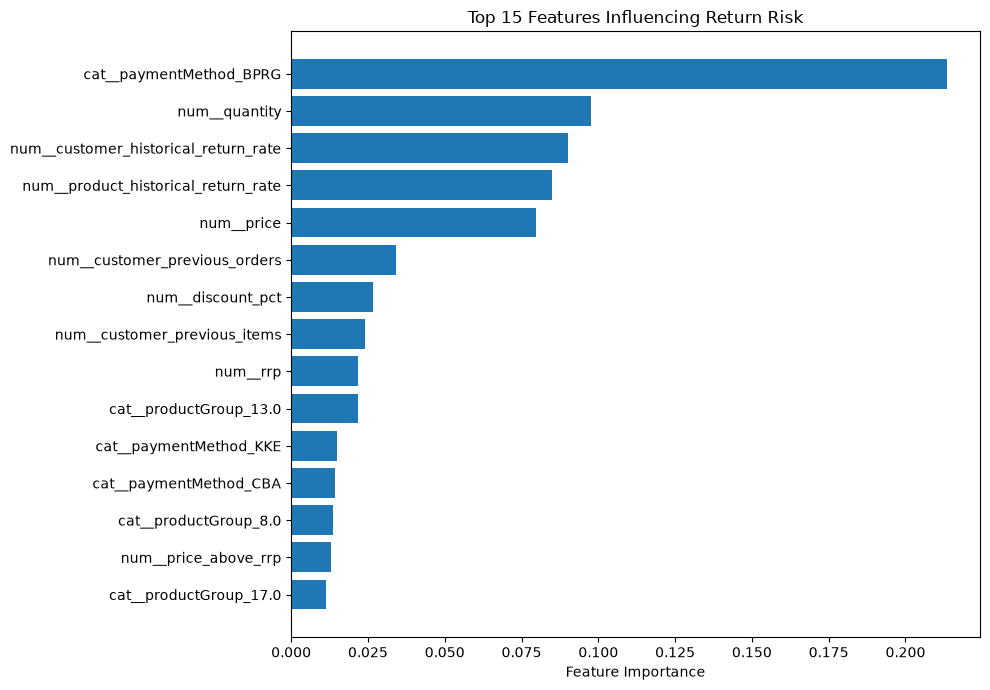

In [37]:
top_features = importance_df.head(15).sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Top 15 Features Influencing Return Risk")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

In [38]:
comparison.to_csv(
    "../models/model_comparison.csv",
    index=False
)

print("Model comparison saved!")

Model comparison saved!
